# Brain Tumor Classification using Original XGBoost

In this notebook, we will implement the original XGBoost approach for brain tumor classification.
The images will be loaded, resized, converted into numerical feature vectors, and then used to train an XGBoost classifier.

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

from xgboost import XGBClassifier

print("Libraries imported successfully.")

Libraries imported successfully.


## Define Dataset Paths

The Brain Tumor dataset is organized into separate Training and Testing folders.
We define these paths once so they can be reused throughout the notebook.

In [7]:
train_path = "/mnt/c/ML Projects/Medical-Image-Classification-Projects/Exersize-1(BrainTumour-SVM)/archive/Training"

test_path = "/mnt/c/ML Projects/Medical-Image-Classification-Projects/Exersize-1(BrainTumour-SVM)/archive/Testing"

classes = sorted(os.listdir(train_path))

print("Classes:")
for cls in classes:
    print("-", cls)

Classes:
- glioma_tumor
- meningioma_tumor
- no_tumor
- pituitary_tumor


## Load and Preprocess Images

In this step, images are loaded from the dataset folders, resized to a fixed size, and converted into feature vectors.
These feature vectors will be used as input for the XGBoost classifier.

In [8]:

IMG_SIZE = 128

def load_images(data_path):
    images = []
    labels = []

    for label in classes:
        folder_path = os.path.join(data_path, label)

        for image_name in os.listdir(folder_path):
            image_path = os.path.join(folder_path, image_name)

            try:
                img = cv2.imread(image_path)

                if img is None:
                    continue

                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                images.append(img.flatten())
                labels.append(label)

            except Exception:
                continue

    return np.array(images), np.array(labels)

## Load and Preprocess the Dataset

Images are loaded from the training folder, converted to grayscale, resized to 200×200 pixels, and flattened into feature vectors.
The resulting dataset will be used for training and evaluation.

In [11]:
# Define classes and their labels

classes = {
    'no_tumor': 0,
    'pituitary_tumor': 1,
    'glioma_tumor': 2,
    'meningioma_tumor': 3
}

X = []
Y = []

for cls, label in classes.items():

    folder_path = os.path.join(train_path, cls)

    for filename in os.listdir(folder_path):

        image_path = os.path.join(folder_path, filename)

        img = cv2.imread(image_path, 0)

        if img is None:
            continue

        img = cv2.resize(img, (200, 200))

        X.append(img.flatten() / 255.0)
        Y.append(label)

X = np.array(X)
Y = np.array(Y)

print("Feature Matrix Shape:", X.shape)
print("Label Vector Shape:", Y.shape)

Feature Matrix Shape: (2870, 40000)
Label Vector Shape: (2870,)


## Split the Dataset

The dataset is divided into training and testing sets.
The same 80-20 split used in Exercise-1 is applied to ensure fair comparison between SVM and XGBoost.

In [12]:
xtrain, xtest, ytrain, ytest = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=10,
    stratify=Y
)

print("Training Samples:", len(xtrain))
print("Testing Samples:", len(xtest))

Training Samples: 2296
Testing Samples: 574


## Train the Original XGBoost Model

An XGBoost classifier is trained using the image feature vectors.
This serves as the baseline XGBoost implementation before performing training percentage experiments.

In [13]:
xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    random_state=10,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1
)

xgb_model.fit(xtrain, ytrain)

print("Model training completed.")

Model training completed.


## Evaluate the XGBoost Model

The trained model is evaluated on both the training and testing datasets.
This helps us measure performance and detect possible overfitting.

In [14]:
train_accuracy = xgb_model.score(xtrain, ytrain)
test_accuracy = xgb_model.score(xtest, ytest)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

Training Accuracy: 1.0000
Testing Accuracy: 0.8955


## Generate Predictions and Classification Metrics

Predictions are generated for the test dataset.
Various performance metrics are then calculated to provide a more detailed evaluation of the classifier.

In [24]:
y_pred = xgb_model.predict(xtest)

print(classification_report(ytest, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.94      0.88        79
           1       0.93      0.98      0.95       165
           2       0.93      0.90      0.92       165
           3       0.86      0.79      0.82       165

    accuracy                           0.90       574
   macro avg       0.89      0.90      0.89       574
weighted avg       0.90      0.90      0.89       574



## Compute Evaluation Metrics

Several evaluation metrics are calculated including accuracy, weighted F1-score, sensitivity, specificity, and the confusion matrix.
These metrics provide a comprehensive assessment of model performance.

In [16]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    confusion_matrix
)

accuracy = accuracy_score(ytest, y_pred)

f1 = f1_score(
    ytest,
    y_pred,
    average='weighted'
)

sensitivity = recall_score(
    ytest,
    y_pred,
    average='weighted'
)

cm = confusion_matrix(ytest, y_pred)

specificity_per_class = []

for i in range(len(cm)):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    tn = cm.sum() - (tp + fn + fp)

    specificity_per_class.append(
        tn / (tn + fp)
    )

specificity = np.mean(specificity_per_class)

print(f"Accuracy    : {accuracy*100:.2f}%")
print(f"F1 Score    : {f1*100:.2f}%")
print(f"Sensitivity : {sensitivity*100:.2f}%")
print(f"Specificity : {specificity*100:.2f}%")

Accuracy    : 89.55%
F1 Score    : 89.45%
Sensitivity : 89.55%
Specificity : 96.50%


## Confusion Matrix

The confusion matrix provides a detailed view of the classification performance for each tumor category.
Diagonal values represent correctly classified samples.

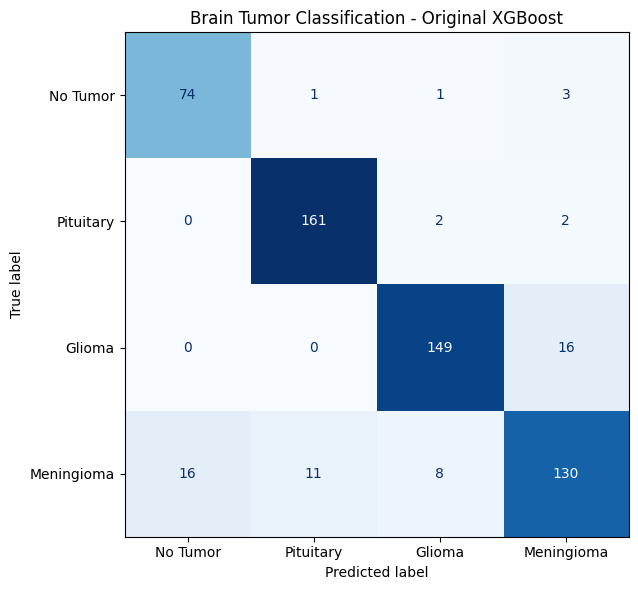

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(ytest, y_pred)

# Plot confusion matrix
class_names = [
    "No Tumor",
    "Pituitary",
    "Glioma",
    "Meningioma"
]

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)

plt.title("Brain Tumor Classification - Original XGBoost")
plt.tight_layout()
plt.show()

## Training Percentage Experiment

To study the effect of training data size, the XGBoost classifier is trained using 20%, 40%, 60%, and 80% of the original training set.
The same test set is used for all experiments to ensure a fair comparison.

In [25]:
training_sizes = [0.2, 0.4, 0.6, 0.8]

xgb_train_scores = []
xgb_test_scores = []

In [26]:
for size in training_sizes:

    x_small, _, y_small, _ = train_test_split(
        xtrain,
        ytrain,
        train_size=size,
        random_state=10,
        stratify=ytrain
    )

    xgb_model = XGBClassifier(
        objective='multi:softmax',
        num_class=4,
        random_state=10,
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1
    )

    xgb_model.fit(x_small, y_small)

    train_acc = xgb_model.score(x_small, y_small)
    test_acc = xgb_model.score(xtest, ytest)

    xgb_train_scores.append(train_acc)
    xgb_test_scores.append(test_acc)

    print(f"\nTraining Size: {int(size*100)}%")
    print(f"Samples: {len(x_small)}")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Testing Accuracy: {test_acc:.4f}")


Training Size: 20%
Samples: 459
Training Accuracy: 1.0000
Testing Accuracy: 0.8066

Training Size: 40%
Samples: 918
Training Accuracy: 1.0000
Testing Accuracy: 0.8345

Training Size: 60%
Samples: 1377
Training Accuracy: 1.0000
Testing Accuracy: 0.8659

Training Size: 80%
Samples: 1836
Training Accuracy: 1.0000
Testing Accuracy: 0.8728


## Accuracy vs Training Percentage

The relationship between training data size and classification accuracy is visualized to study the effect of dataset size on XGBoost performance.

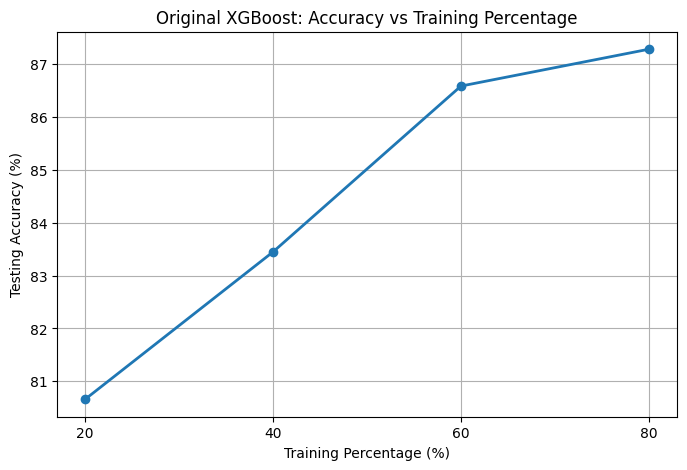

In [27]:
import matplotlib.pyplot as plt

percentages = [20, 40, 60, 80]

plt.figure(figsize=(8, 5))

plt.plot(
    percentages,
    [score * 100 for score in xgb_test_scores],
    marker='o',
    linewidth=2
)

plt.title("Original XGBoost: Accuracy vs Training Percentage")
plt.xlabel("Training Percentage (%)")
plt.ylabel("Testing Accuracy (%)")
plt.xticks(percentages)
plt.grid(True)

plt.show()